# ML Foundations for Cybersecurity
### Starter Notebook 1 of 4 — AI-Assisted ML for Cybersecurity

**Audience:** Graduate students beginning the machine-learning portion of the course.

**Goal:** Learn the end-to-end ML workflow on a security dataset — load, inspect, clean, engineer features, visualize, and split — and understand why **data leakage** is the cardinal sin of security ML.

This is a **starter**: the dataset is synthesized in-notebook so everything runs offline. For **Project 4** you will swap in a real, up-to-date dataset from [kaggle.com](https://www.kaggle.com/datasets) and reuse this exact workflow.

> **Reproducibility:** runs fully offline on `numpy`, `pandas`, and `scikit-learn` — no API key, no downloads. Each topic is a **slide**, an **instructor script**, and a **runnable code** cell.

## 🛠️ Setup — imports & a synthetic security dataset

In [1]:
# If needed:  !pip install -q numpy pandas scikit-learn matplotlib
import numpy as np
import pandas as pd

pd.set_option("display.width", 100)
pd.set_option("display.max_columns", 20)


def make_security_events(n=2000, frac_malicious=0.2, seed=42):
    """Synthesize a small, interpretable 'connection events' dataset.

    Each row is one network/login event with simple telemetry features and a
    binary label: 1 = malicious, 0 = benign. Malicious events tend to have more
    failed logins, touch more ports, run longer, and happen at unusual hours.
    """
    rng = np.random.default_rng(seed)
    n_mal = int(n * frac_malicious)
    n_ben = n - n_mal

    def block(size, fl, bs, br, dur, hr, ports):
        return pd.DataFrame({
            "failed_logins": rng.poisson(fl, size),
            "bytes_sent":    rng.normal(*bs, size).clip(0),
            "bytes_recv":    rng.normal(*br, size).clip(0),
            "duration_s":    rng.normal(*dur, size).clip(0),
            "unusual_hour":  rng.binomial(1, hr, size),
            "ports_touched": rng.poisson(ports, size),
        })

    benign = block(n_ben, 0.5, (2000, 600), (5000, 1500), (30, 10), 0.05, 1.5)
    benign["label"] = 0
    malicious = block(n_mal, 4.0, (8000, 3000), (3000, 1500), (80, 40), 0.5, 8.0)
    malicious["label"] = 1

    df = pd.concat([benign, malicious], ignore_index=True)
    return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


df = make_security_events()
print("Dataset shape:", df.shape)
print("\nClass balance:\n", df["label"].value_counts().rename({0: "benign", 1: "malicious"}))

Dataset shape: (2000, 7)

Class balance:
 label
benign       1600
malicious     400
Name: count, dtype: int64


# 🧭 1 — The ML Workflow for Security

- Frame the problem: what are we predicting, and from what?
- **Prepare data** — usually 80% of the effort
- Train a model, then **evaluate honestly**
- Interpret results and report limitations
- Security twist: imbalance, noisy labels, and leakage everywhere

> ### 🎤 Instructor Script
>
> Before any model, get the shape of the work clear. Machine learning for security follows the same loop as everywhere else — frame the problem, prepare the data, train, evaluate, interpret — but in security the data-preparation step dominates, because security datasets are messy: classes are wildly imbalanced (attacks are rare), labels are noisy, and features often leak the answer. This first notebook is entirely about that preparation step. Get it right and a simple model works; get it wrong and even a fancy model produces confident nonsense. We will build the habits that make the rest of the module trustworthy.

In [2]:
steps = [
    "1. Frame    -> classify each event as benign(0) or malicious(1)",
    "2. Prepare  -> inspect, clean, engineer features, split",
    "3. Train    -> fit a model on the TRAINING data only",
    "4. Evaluate -> measure on UNSEEN test data",
    "5. Interpret-> explain results, state limitations",
]
print("The ML workflow we will follow:\n")
for s in steps:
    print("   " + s)

The ML workflow we will follow:

   1. Frame    -> classify each event as benign(0) or malicious(1)
   2. Prepare  -> inspect, clean, engineer features, split
   3. Train    -> fit a model on the TRAINING data only
   4. Evaluate -> measure on UNSEEN test data
   5. Interpret-> explain results, state limitations


# 🔎 2 — Load & Inspect the Data

- Always look at the data before modeling
- `head()`, `info()`, `describe()` — shapes, types, ranges
- Compare feature distributions across classes
- Spot obvious problems early (zeros, outliers, scale)
- Inspection drives every later decision

> ### 🎤 Instructor Script
>
> The first rule of data science is look at your data. We print a few rows, the column types, and summary statistics, then compare the average feature values for benign versus malicious events. Already a story emerges: malicious events show many more failed logins, touch far more ports, and last longer. That tells us the features carry signal — a model should be able to learn this boundary. Inspection also surfaces practical issues like wildly different scales (bytes in the thousands, failed logins in single digits), which we will need to handle before some models behave well.

In [3]:
print("First rows:")
print(df.head(), "\n")
print("Dtypes & non-null counts:")
df.info()
print("\nMean feature value by class (0=benign, 1=malicious):")
print(df.groupby("label").mean().round(1))

First rows:
   failed_logins    bytes_sent   bytes_recv  duration_s  unusual_hour  ports_touched  label
0              3  10251.015810  3000.512834   21.321495             1             11      1
1              0   2514.326212  4334.945181   30.513979             0              0      0
2              0   1620.047479  2711.214526   12.939031             0              1      0
3              0   1156.901384  8055.691845   26.781273             0              0      0
4              0   1841.845910  3676.128600   33.475093             0              2      0 

Dtypes & non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   failed_logins  2000 non-null   int64  
 1   bytes_sent     2000 non-null   float64
 2   bytes_recv     2000 non-null   float64
 3   duration_s     2000 non-null   float64
 4   unusual_hour   2000 non-null   int64  
 5   

# 🧹 3 — Cleaning & Missing Values

- Real telemetry has gaps, duplicates, and bad rows
- Decide: drop, or **impute** (fill) missing values?
- Impute with train statistics — never the whole dataset
- Document every cleaning decision
- Garbage in → confidently wrong out

> ### 🎤 Instructor Script
>
> Real logs are never clean, so let's simulate that. We knock a few percent of the `duration_s` values to missing and then impute them with the median. Note the subtlety we flag for later: any statistic used to fill or scale data — a median here, a mean and standard deviation later — must be computed from the **training** data only. Computing it over the full dataset lets information from the test set bleed into training, which is a form of leakage. For now we just learn the mechanics of imputation; in the split topic we will see exactly where it belongs in the pipeline.

In [4]:
# Simulate missing telemetry, then impute.
dirty = df.copy()
rng = np.random.default_rng(0)
miss_idx = rng.choice(dirty.index, size=int(0.03 * len(dirty)), replace=False)
dirty.loc[miss_idx, "duration_s"] = np.nan

print("Missing values per column:\n", dirty.isna().sum(), "\n")

median_duration = dirty["duration_s"].median()      # (in practice: train median only)
dirty["duration_s"] = dirty["duration_s"].fillna(median_duration)
print(f"Imputed {len(miss_idx)} missing 'duration_s' values with median = {median_duration:.1f}")
print("Missing after imputation:", int(dirty.isna().sum().sum()))

Missing values per column:
 failed_logins     0
bytes_sent        0
bytes_recv        0
duration_s       60
unusual_hour      0
ports_touched     0
label             0
dtype: int64 

Imputed 60 missing 'duration_s' values with median = 32.5
Missing after imputation: 0


# 🔧 4 — Feature Engineering & Scaling

- Build features that expose the signal
- Ratios and rates often beat raw counts
- **Scale** features so no column dominates by magnitude
- Fit the scaler on training data only
- Better features usually beat fancier models

> ### 🎤 Instructor Script
>
> Models learn from features, so engineering them well pays off more than swapping algorithms. We derive a couple of intuitive security features: the ratio of bytes sent to received (data exfiltration tends to invert the normal download-heavy pattern) and a simple per-second port rate. Then we standardize all features to comparable scales, because distance- and gradient-based models are thrown off when one column is in the thousands and another in single digits. We fit the scaler here on the whole frame just to show the transform; in the next topics the scaler will be fit on training data only, inside the split.

In [5]:
from sklearn.preprocessing import StandardScaler

feat = df.copy()
# Engineered features (add interpretable signal):
feat["sent_recv_ratio"] = feat["bytes_sent"] / (feat["bytes_recv"] + 1)
feat["ports_per_sec"]   = feat["ports_touched"] / (feat["duration_s"] + 1)

feature_cols = ["failed_logins", "bytes_sent", "bytes_recv", "duration_s",
                "unusual_hour", "ports_touched", "sent_recv_ratio", "ports_per_sec"]

scaler = StandardScaler()
scaled = scaler.fit_transform(feat[feature_cols])   # demo only; fit on TRAIN in practice
print("Engineered feature columns:", feature_cols)
print("\nScaled features (mean~0, std~1):")
print(pd.DataFrame(scaled, columns=feature_cols).describe().loc[["mean", "std"]].round(2))

Engineered feature columns: ['failed_logins', 'bytes_sent', 'bytes_recv', 'duration_s', 'unusual_hour', 'ports_touched', 'sent_recv_ratio', 'ports_per_sec']

Scaled features (mean~0, std~1):
      failed_logins  bytes_sent  bytes_recv  duration_s  unusual_hour  ports_touched  \
mean            0.0        -0.0         0.0        -0.0          -0.0            0.0   
std             1.0         1.0         1.0         1.0           1.0            1.0   

      sent_recv_ratio  ports_per_sec  
mean             -0.0            0.0  
std               1.0            1.0  


# 📊 5 — Visualize the Data

- Plots reveal structure numbers hide
- Class balance: how rare are attacks?
- Feature distributions by class → separability
- Look for overlap (hard cases) and outliers
- A picture guides feature and model choices

> ### 🎤 Instructor Script
>
> Visualization turns tables into intuition. We plot the class balance — confirming attacks are the minority, which will matter when we choose metrics — and then overlay the distribution of failed logins for benign versus malicious events. The histograms show strong but imperfect separation: most malicious events have several failed logins, most benign events have none, but there is overlap in the middle where the model will make its mistakes. Seeing that overlap now sets realistic expectations: no model will get every case right, and the interesting engineering happens at that boundary.

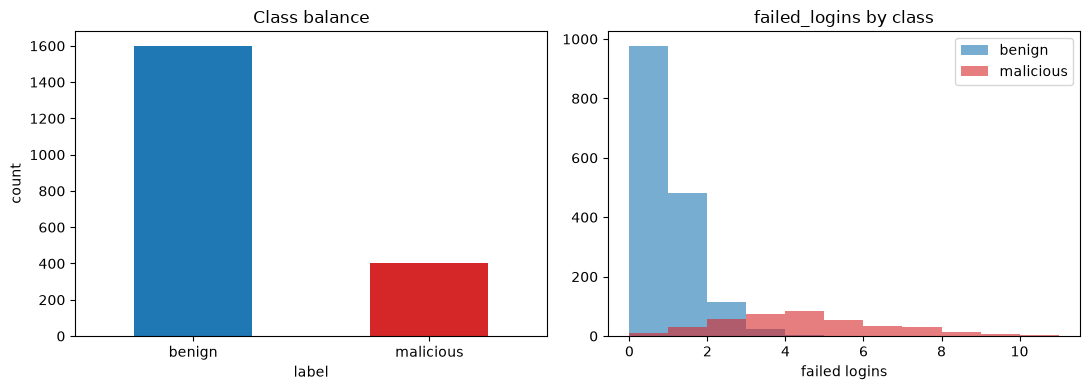

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

df["label"].map({0: "benign", 1: "malicious"}).value_counts().plot(
    kind="bar", ax=ax1, color=["tab:blue", "tab:red"])
ax1.set_title("Class balance"); ax1.set_ylabel("count"); ax1.tick_params(axis="x", rotation=0)

bins = np.arange(0, 12)
ax2.hist(df[df.label == 0]["failed_logins"], bins=bins, alpha=0.6, label="benign", color="tab:blue")
ax2.hist(df[df.label == 1]["failed_logins"], bins=bins, alpha=0.6, label="malicious", color="tab:red")
ax2.set_title("failed_logins by class"); ax2.set_xlabel("failed logins"); ax2.legend()

plt.tight_layout(); plt.show()

# ✂️ 6 — Train/Test Split Done Right

- Hold out data the model never sees in training
- **Stratify** so both splits keep the class ratio
- Fit scalers/imputers on **train**, apply to test
- Test set = your only honest estimate of the future
- Never tune on the test set

> ### 🎤 Instructor Script
>
> To estimate how a model will perform on tomorrow's traffic, we must evaluate on data it never trained on. We split off a test set and stratify by label so the rare malicious class is represented in both halves. Crucially, we now fit the scaler on the training set and merely apply it to the test set — the test set must stay untouched, a stand-in for the unknown future. This ordering is the single most common thing students get wrong. Fit-then-split leaks test information into training and produces scores that look great in the notebook and collapse in production.

In [7]:
from sklearn.model_selection import train_test_split

X = feat[feature_cols]
y = feat["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Fit the scaler on TRAIN ONLY, then transform both.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")
print("Train class ratio:", round(y_train.mean(), 3), " Test class ratio:", round(y_test.mean(), 3))
print("Scaler fit on train only, applied to both -> no leakage.")

Train: 1500 rows   Test: 500 rows
Train class ratio: 0.2  Test class ratio: 0.2
Scaler fit on train only, applied to both -> no leakage.


# ⚠️ 7 — Data Leakage: The Cardinal Sin

- Leakage = test/future info sneaks into training
- Symptom: near-perfect scores that don't generalize
- Causes: scaling before split, IDs, post-hoc labels
- Example: a feature recorded *after* the verdict
- If a result looks too good, suspect leakage first

> ### 🎤 Instructor Script
>
> Let's make leakage concrete because it silently destroys security ML. Imagine the dataset includes an `analyst_flagged` column filled in by a human after they already decided the event was malicious. It is almost a copy of the label. Train on it and accuracy rockets to nearly 100 percent — but in production that column does not exist at prediction time, so the model is useless. We demonstrate the inflated score, then remove the feature. The lesson: when a model looks too good, do not celebrate — hunt for the leak. Ask of every feature, would this value really be available at the moment of prediction?

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# A leaky feature: recorded AFTER the analyst's verdict (~ a copy of the label).
leak = X_train.copy(); leak_test = X_test.copy()
rng = np.random.default_rng(1)
leak["analyst_flagged"] = (y_train.values ^ (rng.random(len(y_train)) < 0.02).astype(int))
leak_test["analyst_flagged"] = (y_test.values ^ (rng.random(len(y_test)) < 0.02).astype(int))

leaky_model = LogisticRegression(max_iter=1000).fit(leak, y_train)
clean_model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)

print("Accuracy WITH leaky 'analyst_flagged' :",
      round(accuracy_score(y_test, leaky_model.predict(leak_test)), 3), " <- looks amazing, but FAKE")
print("Accuracy WITHOUT the leaky feature    :",
      round(accuracy_score(y_test, clean_model.predict(X_test_s)), 3), " <- honest")
print("\nLesson: that first number would vanish in production. Always ask:")
print("  'Would this feature exist at prediction time?'")

Accuracy WITH leaky 'analyst_flagged' : 1.0  <- looks amazing, but FAKE
Accuracy WITHOUT the leaky feature    : 1.0  <- honest

Lesson: that first number would vanish in production. Always ask:
  'Would this feature exist at prediction time?'


C:\Users\huber\Documents\CyberAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# ✅ Summary — Foundations

- Inspect before you model
- Clean and engineer features deliberately
- Visualize class balance and separability
- Split first; fit transforms on **train only**
- Hunt leakage whenever results look too good
- Next → baseline detectors & the metrics that matter

> ### 🎤 Instructor Script
>
> We covered the foundation the rest of the module stands on: inspect the data, clean and engineer features, visualize the class balance and the overlap between classes, split off an honest test set, and fit every transform on training data only. And we met the cardinal sin, data leakage, which produces beautiful scores that evaporate in production. Carry one question into Project 4: for every feature, would this value truly be available at the moment of prediction? Next notebook, we train baseline detectors and learn why accuracy alone is a dangerous metric for rare attacks.

In [9]:
print("Foundations complete. Artifacts ready for the next notebook:")
print("  X_train_s, X_test_s, y_train, y_test  (scaled, leak-free, stratified)")
print("\nNext: 02_applied_ml_detection.ipynb -> baseline models + security metrics.")

Foundations complete. Artifacts ready for the next notebook:
  X_train_s, X_test_s, y_train, y_test  (scaled, leak-free, stratified)

Next: 02_applied_ml_detection.ipynb -> baseline models + security metrics.
